In [19]:
from histpy import Histogram, HealpixAxis, Axis, Axes
from mhealpy import HealpixMap
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic

from cosipy.response import FullDetectorResponse, PointSourceResponse, GalacticResponse
# from cosipy.spacecraftfile import SpacecraftFile
# from cosipy.ts_map.TSMap import TSMap
from cosipy.data_io import UnBinnedData, BinnedData
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.ts_map import FastNormFit, FastTSMap
from cosipy.util import fetch_wasabi_file

# cosipy uses astropy units
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table
from astropy.io import fits
from scoords import Attitude, SpacecraftFrame

#3ML is needed for spectral modeling
from threeML import *
from astromodels import Band
import h5py

#Other standard libraries
import os
import glob
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cycler
from matplotlib.gridspec import GridSpec 

import healpy as hp
from tqdm.autonotebook import tqdm

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

In [2]:
import numba
numba.set_num_threads(1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


#### Preprocessing

In [ ]:
# hist = Histogram.open('../../DC3/data/responses/extended_source_response_Fe60_low_merged.h5')

# new_axes = []

# axis = hist.axes[0]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

# for axis in hist.axes[1:3]:
#     new_axes += [Axis(np.array([1154, 1160]) * u.keV,
#                     label = axis.label,
#                     scale = axis.axis_scale)]

# axis = hist.axes[3]
# new_axes += [Axis(axis.edges, label = axis.label,
#                   scale = axis.axis_scale)]

# axis = hist.axes[4]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

In [ ]:
# new_hist = Histogram(new_axes,
#                            contents=hist.contents,
#                            sparse=hist.is_sparse,
#                            unit=hist.unit)

# new_hist.write('psr.h5')

In [ ]:
# # Load all 14 weeks of data
# filenames = sorted(glob.glob('../data/*.fits'))
# data_obj.get_binned_data(filenames[0])

# for filename in filenames[1:]:
#     data_loader_obj.get_binned_data(filename)
#     data_obj.binned_data = data_obj.binned_data + data_loader_obj.binned_data

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimensi

In [ ]:
# data_obj.binned_data.write('44Ti_binned_data.hdf5')

### Data Loading

In [3]:
# psr = GalacticResponse.open('psr.h5')
# psr = Histogram.open('psr.h5')
psr_filename = '/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/data/responses/extended_source_response_Ti44_merged.h5'
psr = Histogram.open(psr_filename)

In [4]:
# Create binned data object for sources
data_obj = BinnedData("inputs.yaml")
data_loader_obj = BinnedData("inputs.yaml")

# Create binned data object for background
bg_obj = BinnedData("inputs.yaml")

In [5]:
data_obj.load_binned_data_from_hdf5('44Ti_binned_data.hdf5')
bg_obj.load_binned_data_from_hdf5('../data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5')

In [6]:
data = data_obj.binned_data     # Need all 3 months data to use with pre-computed response and background
bg = bg_obj.binned_data

In [7]:
# Crab
crab = BinnedData('inputs.yaml')
crab.get_binned_data(unbinned_data = '../../DC3/Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')

# Cas A
casa = BinnedData('inputs.yaml')
casa.get_binned_data(unbinned_data = 'sources/CasAG16distribution_3months_unbinned_data_filtered_with_SAAcut.fits')

# Alternately, use source injector to create template models
# Use the same pre-computed response file with a fairly representative
# flux. For a narrow 1154-1160 keV energy bin, the exact spectral 
# shape wouldn't matter (i.e., wouldn't impart any biases in the Phi,
# PsiChi axes)

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


In [12]:
F = 1e-6 * u.ph / u.cm / u.cm / u.s
mu = 1173.2 * u.keV
sigma = 5 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

## Image Deconvolution

In [12]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": bg.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None,
                                    #   is_miniDC2_format=False
                                      )

In [17]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/50 [00:00<?, ?it/s]

[{'iteration': 48,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x17e234be0>,
  'prior_filter': <histpy.histogram.Histogram at 0x17e1c5ba0>,
  'background_normalization': {'total': <Quantity 1.04590845>},
  'log-likelihood': [<Quantity -121619.89755903>],
  'log-prior': {'gamma_model': <Quantity 45.17640108>,
   'gamma_bkg': <Quantity 0.>},
  'log-posterior': -121574.72115794869},
 {'iteration': 49,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x17e1c7df0>,
  'prior_filter': <histpy.histogram.Histogram at 0x17e206c50>,
  'background_normalization': {'total': <Quantity 1.04601445>},
  'log-likelihood': [<Quantity -121618.90575333>],
  'log-prior': {'gamma_model': <Quantity 45.39913473>,
   'gamma_bkg': <Quantity 0.>},
  'log-posterior': -121573.50661859356},
 {'iteration': 50,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x17e206050>,
  'prior_filter': <histpy.histogram.Histogram at 0x17e1a5780>,
  'background

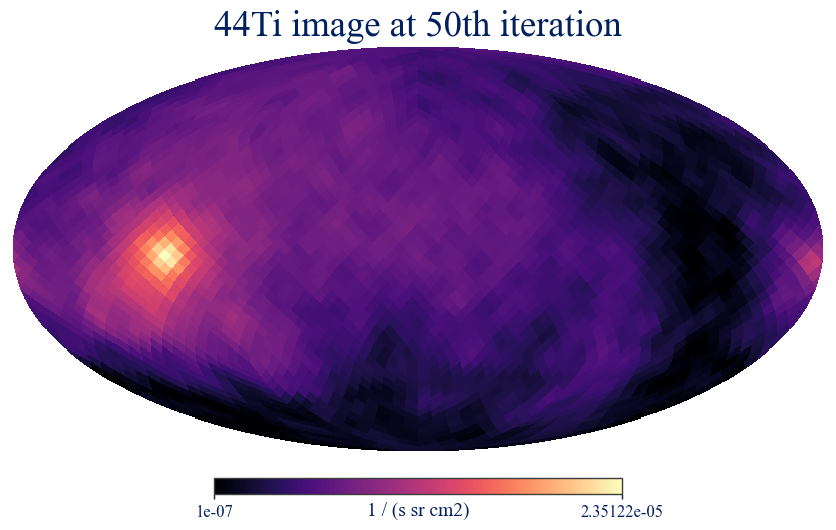

In [18]:
iteration_idx = 49

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

im = image[:,0]
im[im <= 0 * im.unit] = 1e-12 * im.unit

hp.mollview(im, min = 1e-7, norm ='log', unit = str(im.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

plt.show()

In [131]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")
        plt.show()

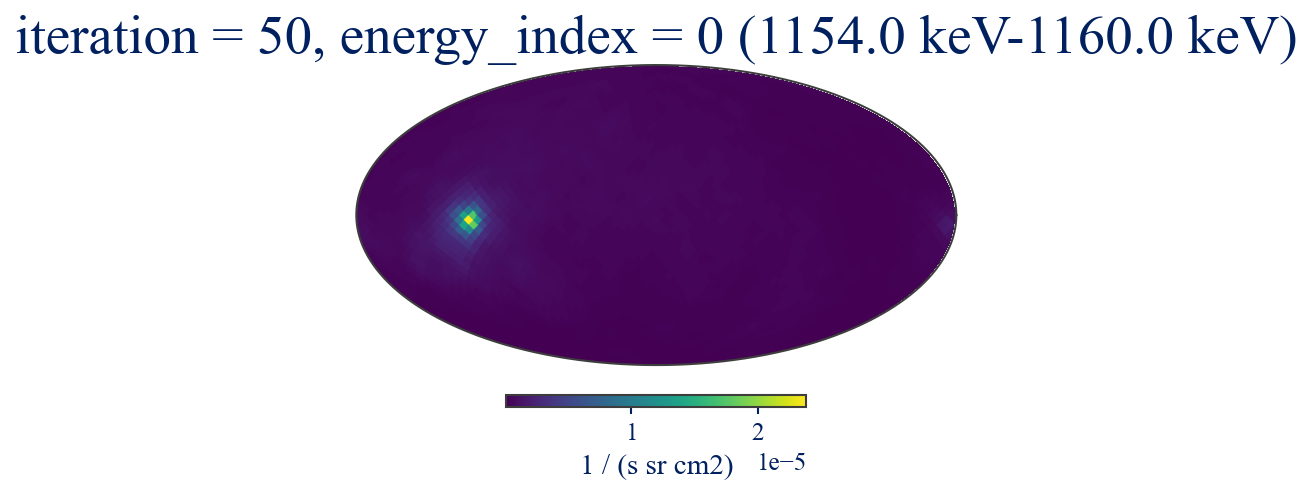

In [132]:
iteration = 49

plot_reconstructed_image(image_deconvolution.results[iteration])

## TS Map

In [7]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi'), 
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


112.93372198951465
1359


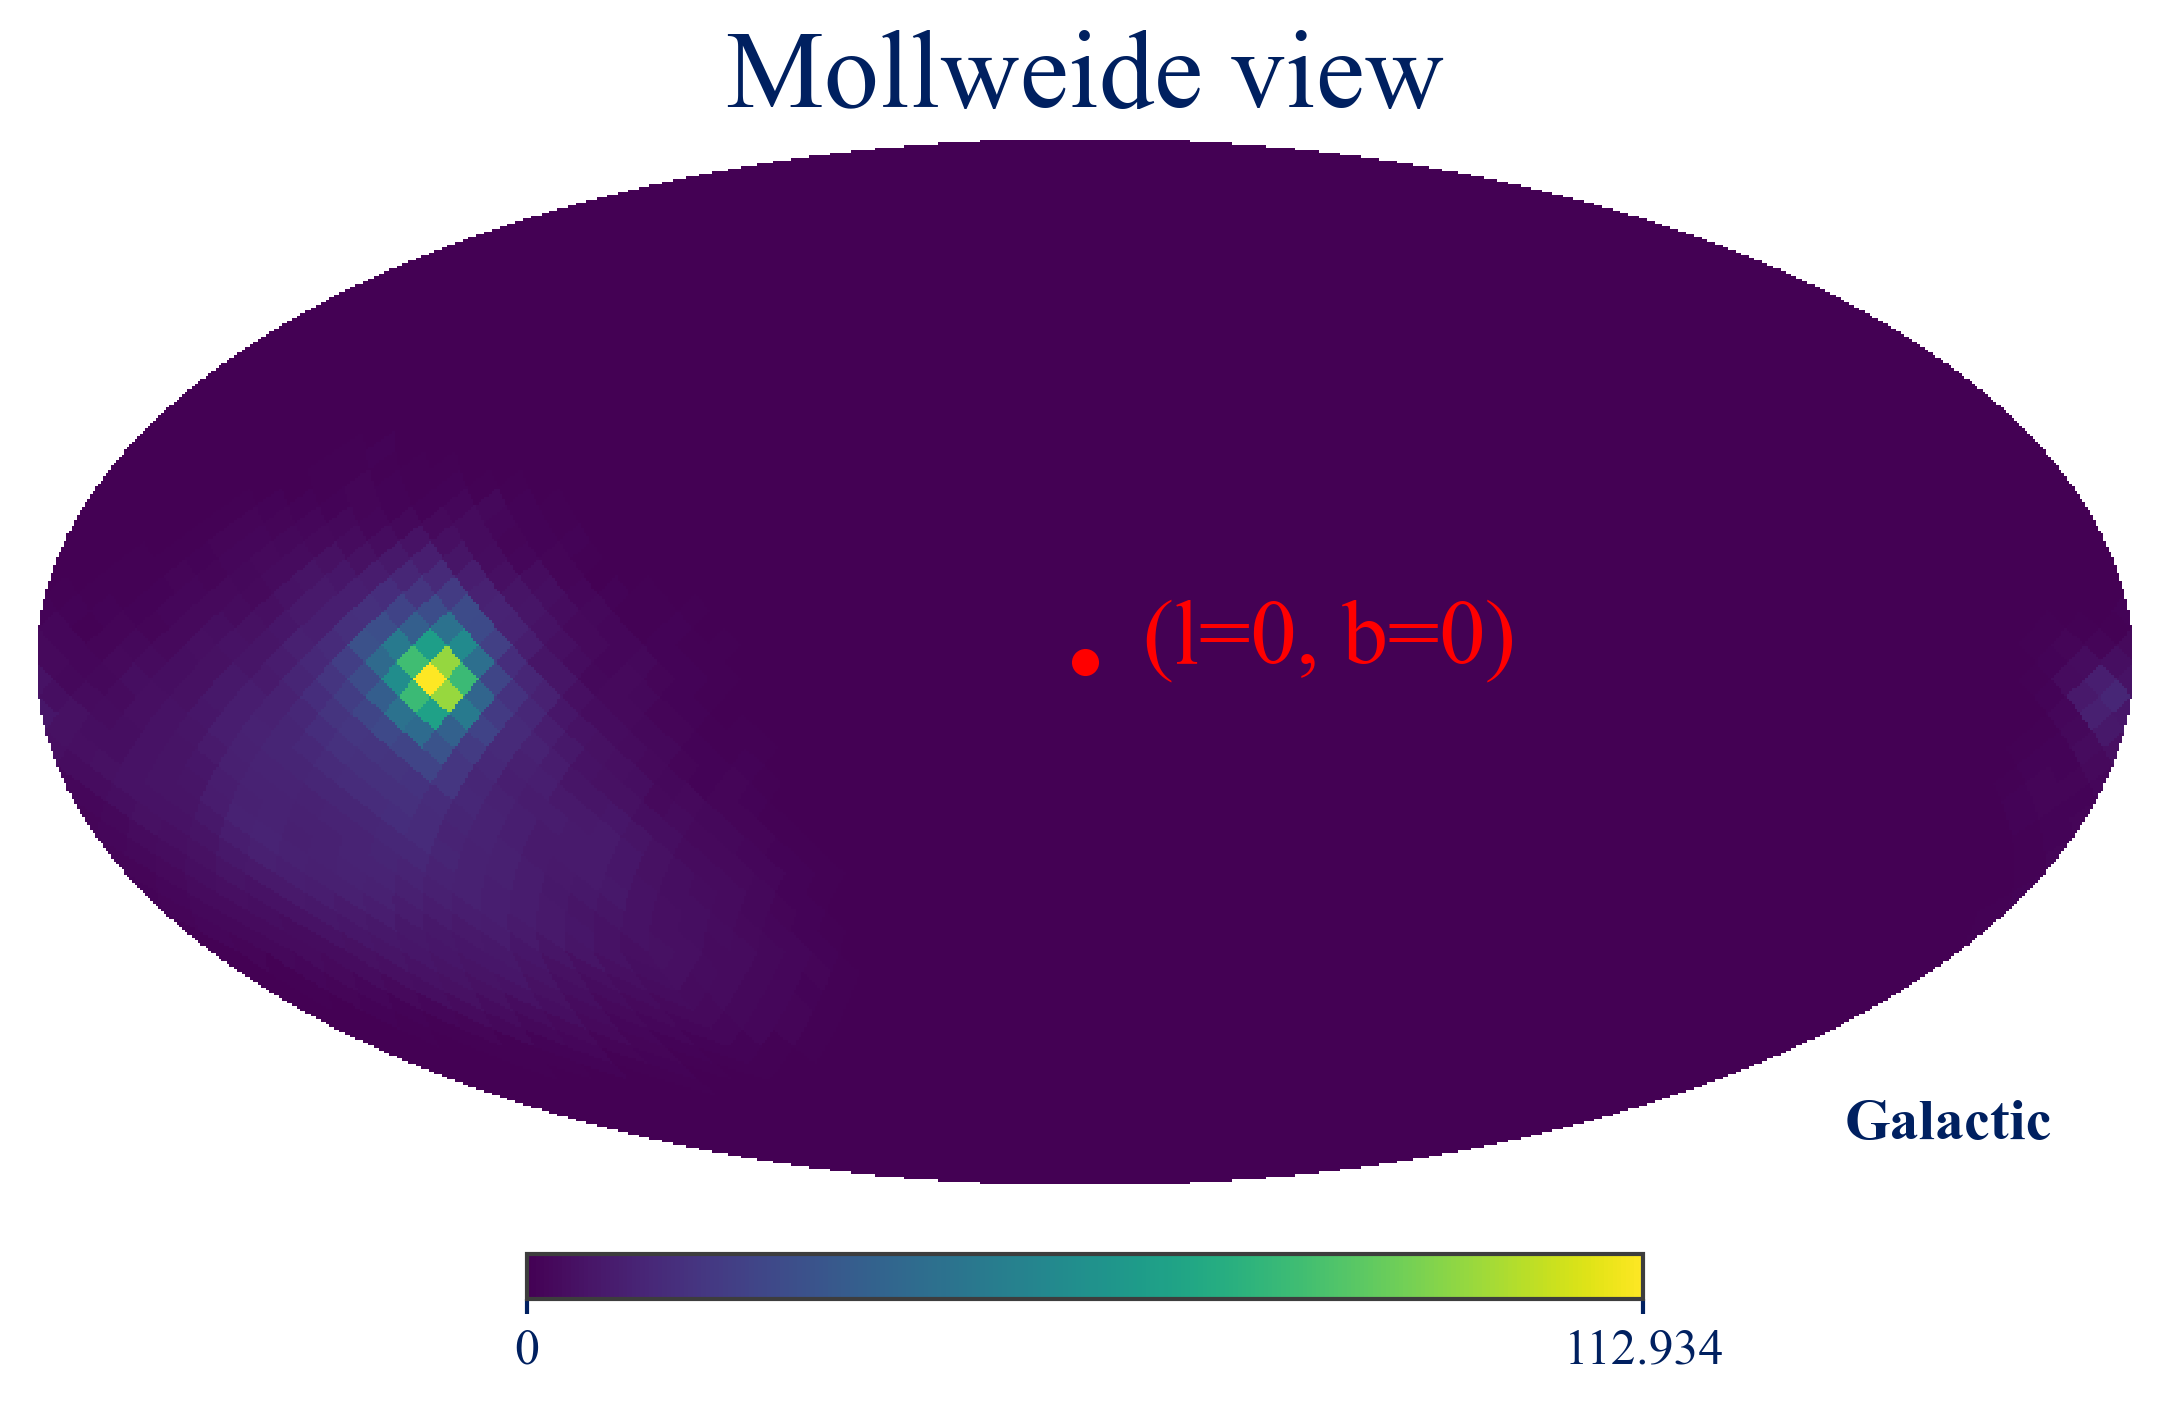

In [8]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

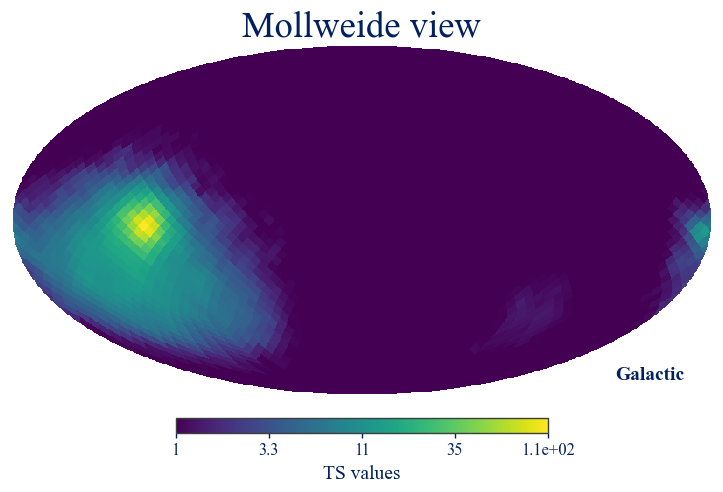

In [15]:
hp.mollview(ts_results+1, nest=True, coord = "G", hold = True, norm='log')
# hp.projscatter(279.7, -31.2, marker = "o", lonlat=True, coord = "G", color = "red")
# hp.projscatter(111.7, -2.1, marker = "o", lonlat=True, coord = "G", color = "red")
cbar = plt.gcf().axes[1]
cbar.set_xticks(np.geomspace(cbar.get_xlim()[0], cbar.get_xlim()[1], 5))
cbar.set_xticklabels([f'{x:.2g}' for x in np.geomspace(cbar.get_xlim()[0], cbar.get_xlim()[1], 5)])
cbar.set_xlabel('TS values')
plt.show()

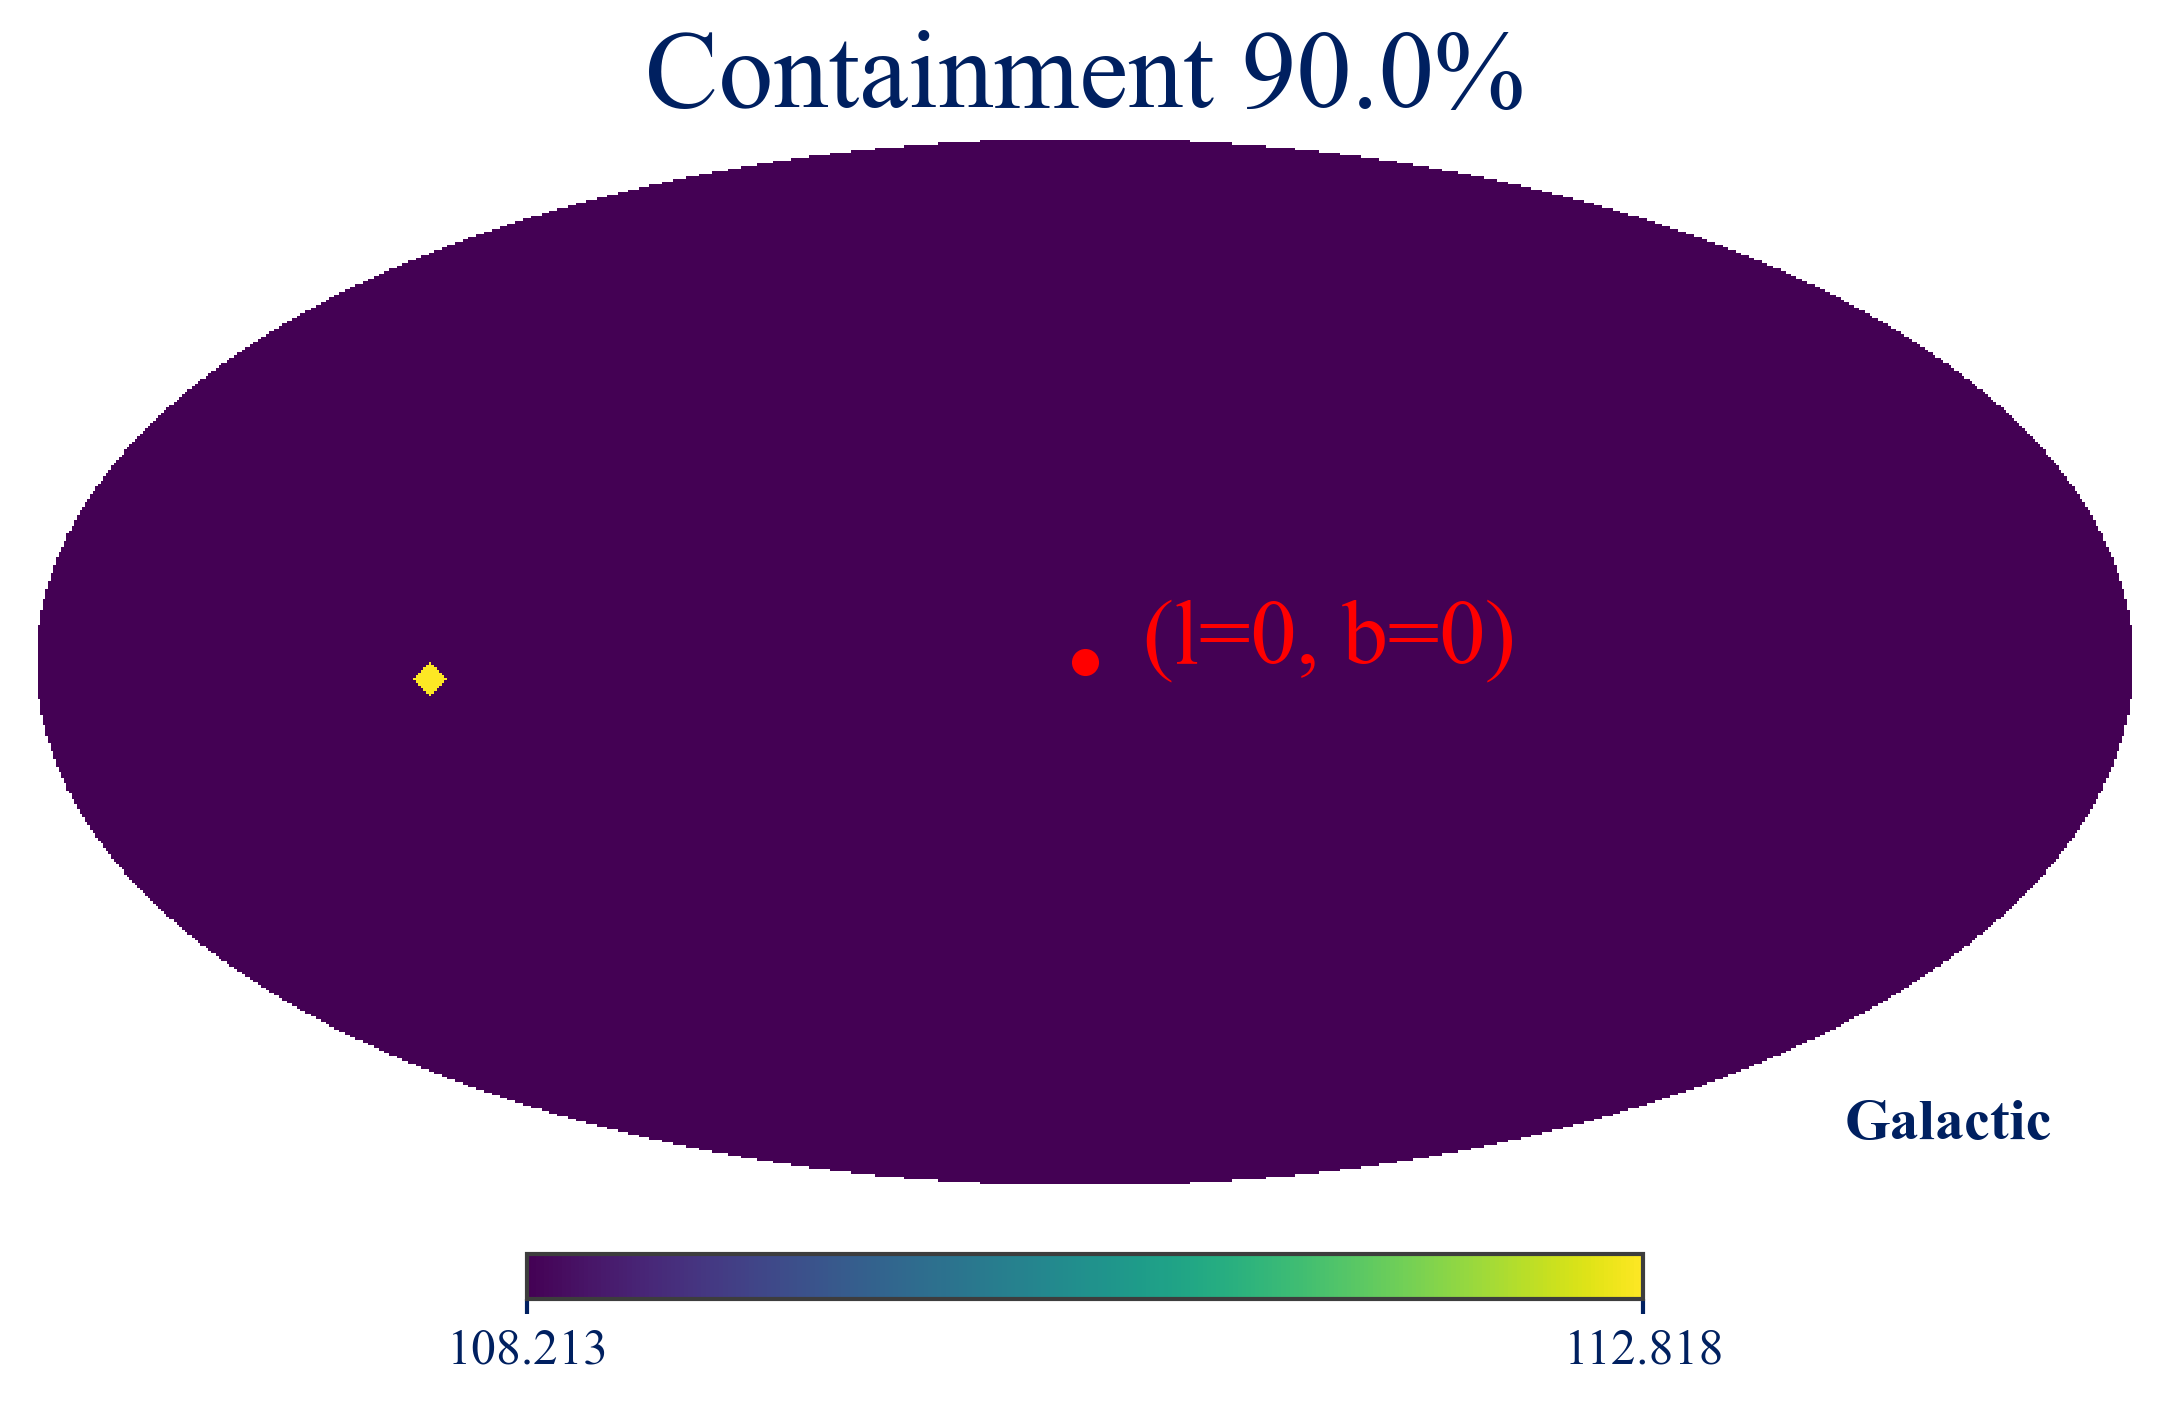

In [220]:
ts.plot_ts(ts_results, containment = 0.9)

## Crab and Cas A as background

In [9]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi') + \
                           crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                           casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

1.539779039423422
2513


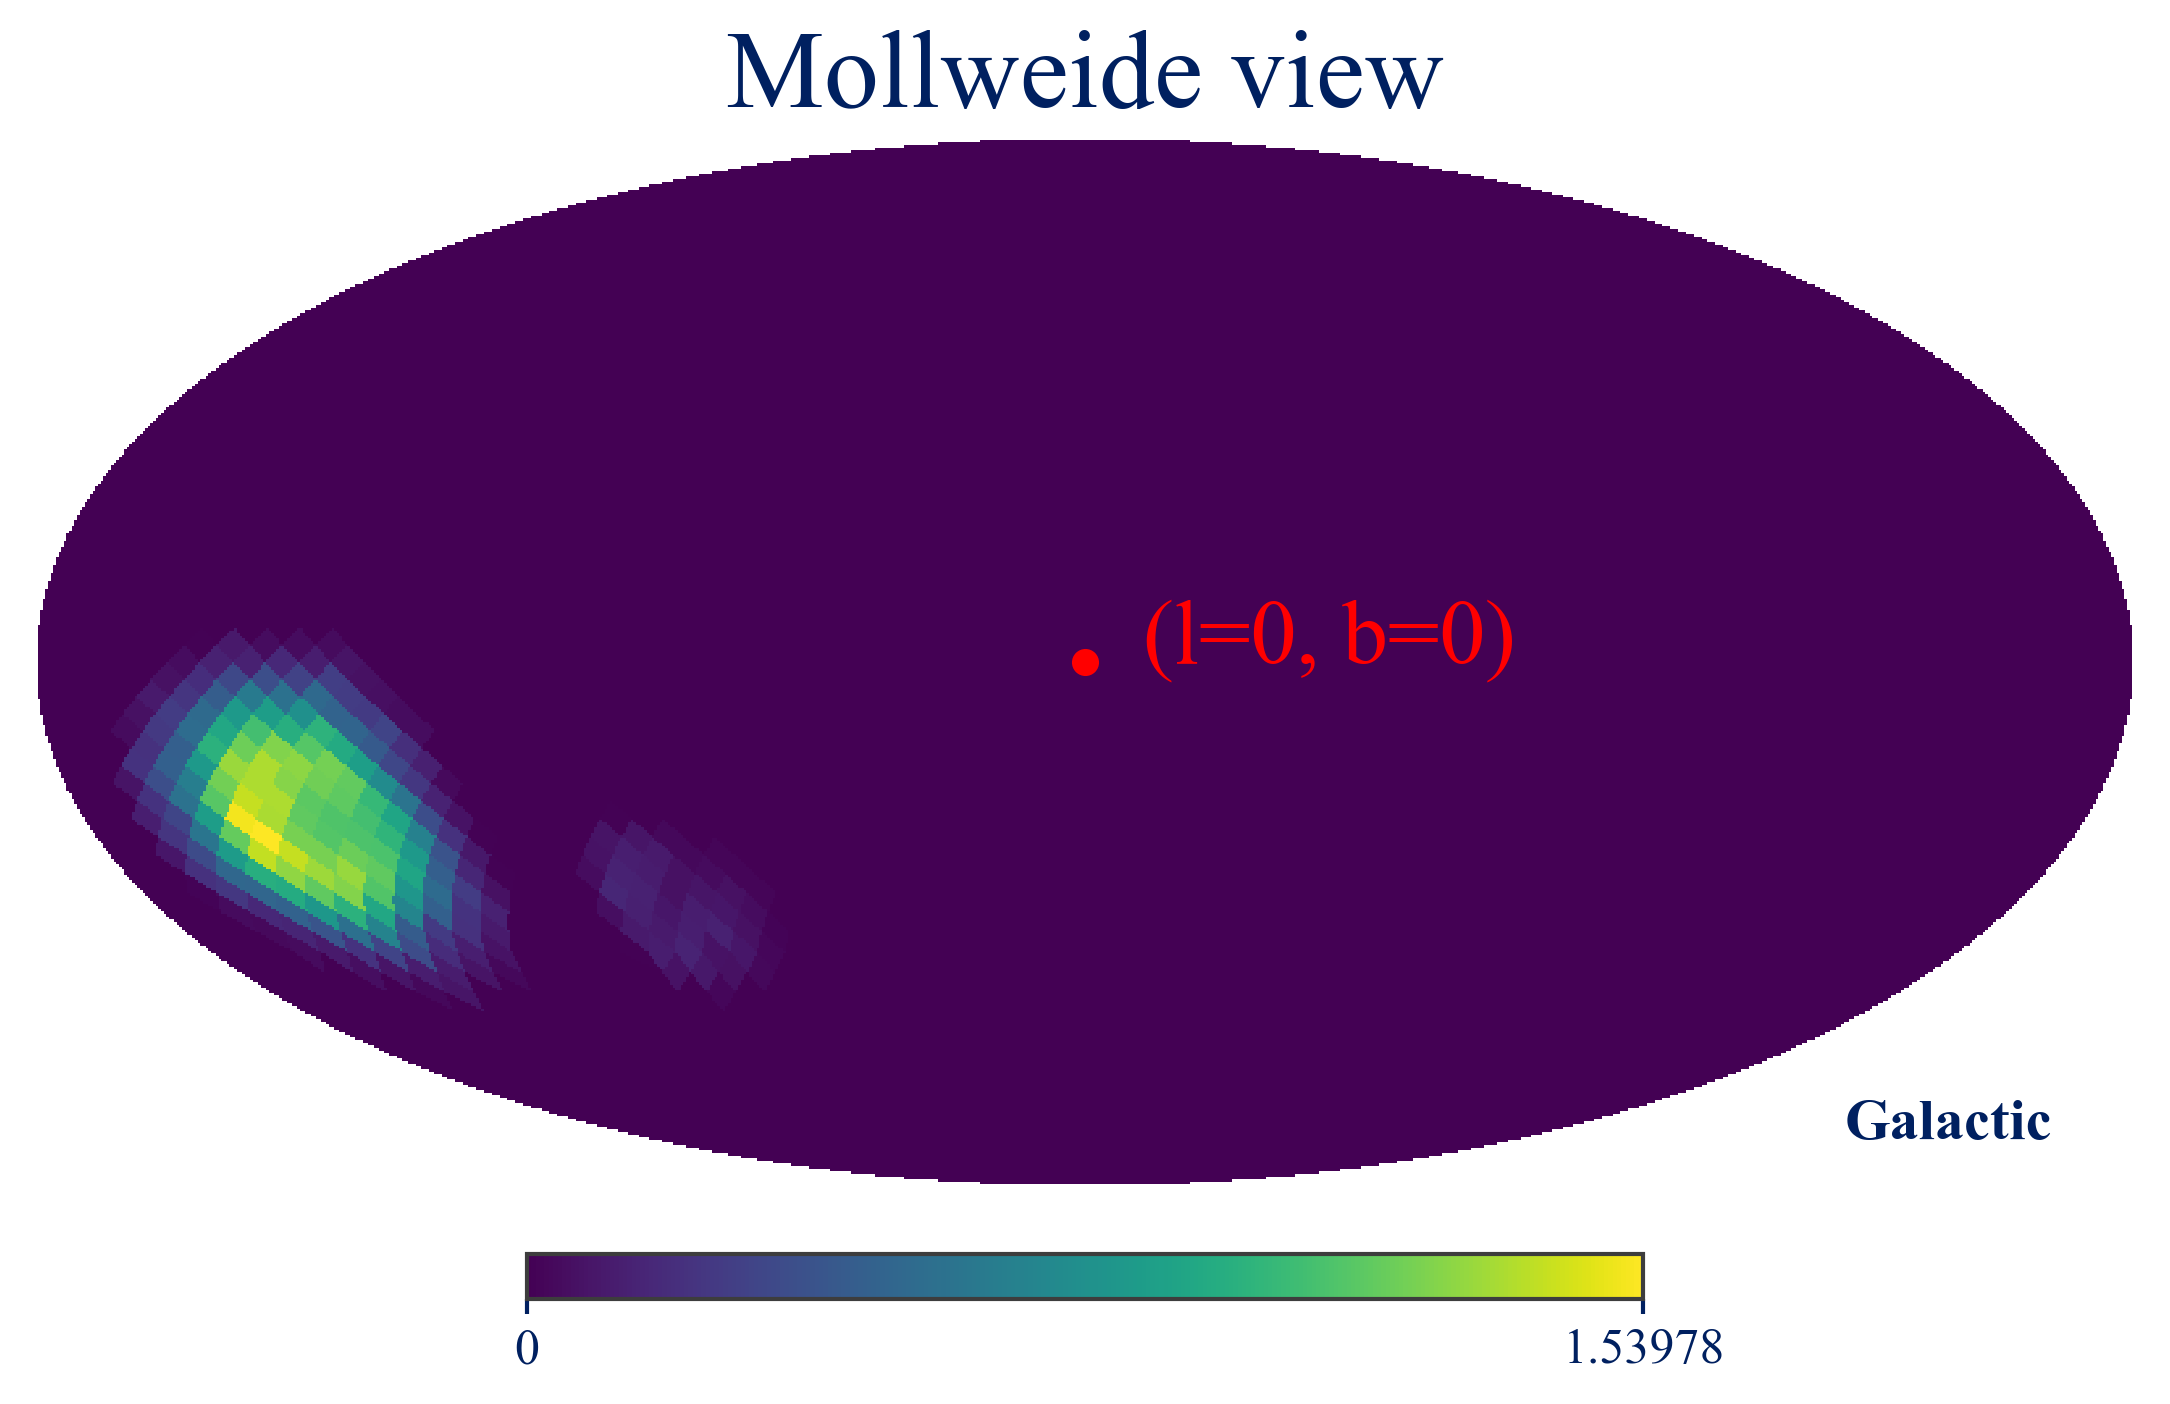

In [10]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [51]:
hp.pix2ang(16, 2516, nest=True, lonlat=True)

(151.875, -22.02431283704216)

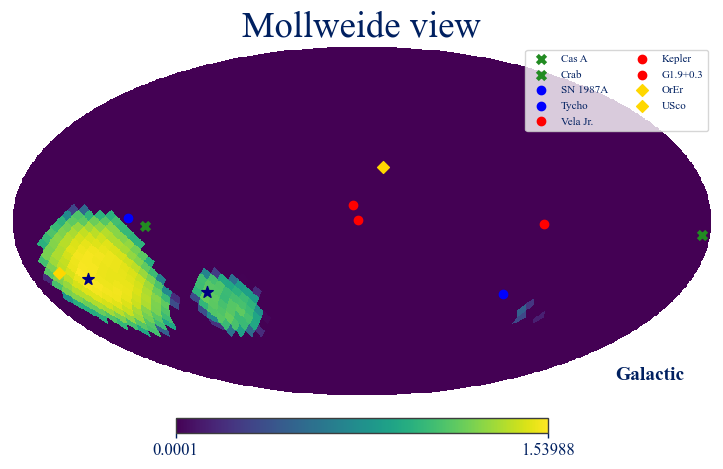

In [178]:
hp.mollview(ts_results+0.0001, nest=True, coord = "G", hold = True, norm='log')
hp.projscatter(111.7, -2.1, marker = "x", lonlat=True, coord = "G", color = "forestgreen", label='Cas A')
hp.projscatter(184.56, -5.78, marker = "x", lonlat=True, coord = "G", color = "forestgreen", label='Crab')
hp.projscatter(279.7, -31.2, marker = "o", lonlat=True, coord = "G", color = "blue", label='SN 1987A')
hp.projscatter(120.1,  1.4, marker = "o", lonlat=True, coord = "G", color = "blue", label='Tycho')
hp.projscatter(266.3, -1.21, marker = "o", lonlat=True, coord = "G", color = "red", label='Vela Jr.')
hp.projscatter(4.5, 6.8, marker = "o", lonlat=True, coord = "G", color = "red", label='Kepler')
hp.projscatter(1.9, 0.3, marker = "o", lonlat=True, coord = "G", color = "red", label='G1.9+0.3')
hp.projscatter(163, -22, marker = "D", lonlat=True, coord = "G", color = "gold", label='OrEr')
hp.projscatter(348.5, 22.5, marker = "D", lonlat=True, coord = "G", color = "gold", label='USco')

patch1 = hp.pix2ang(16, np.argmax(ts_results), True, True)
hp.projscatter(*patch1, marker = "*", s=75, lonlat=True, coord = "G", color = "navy")

patch2 = hp.pix2ang(16, np.argsort(ts_results)[-132], True, True)
hp.projscatter(*patch2, marker = "*", s=75, lonlat=True, coord = "G", color = "navy")

plt.legend(ncols=2)
plt.show()

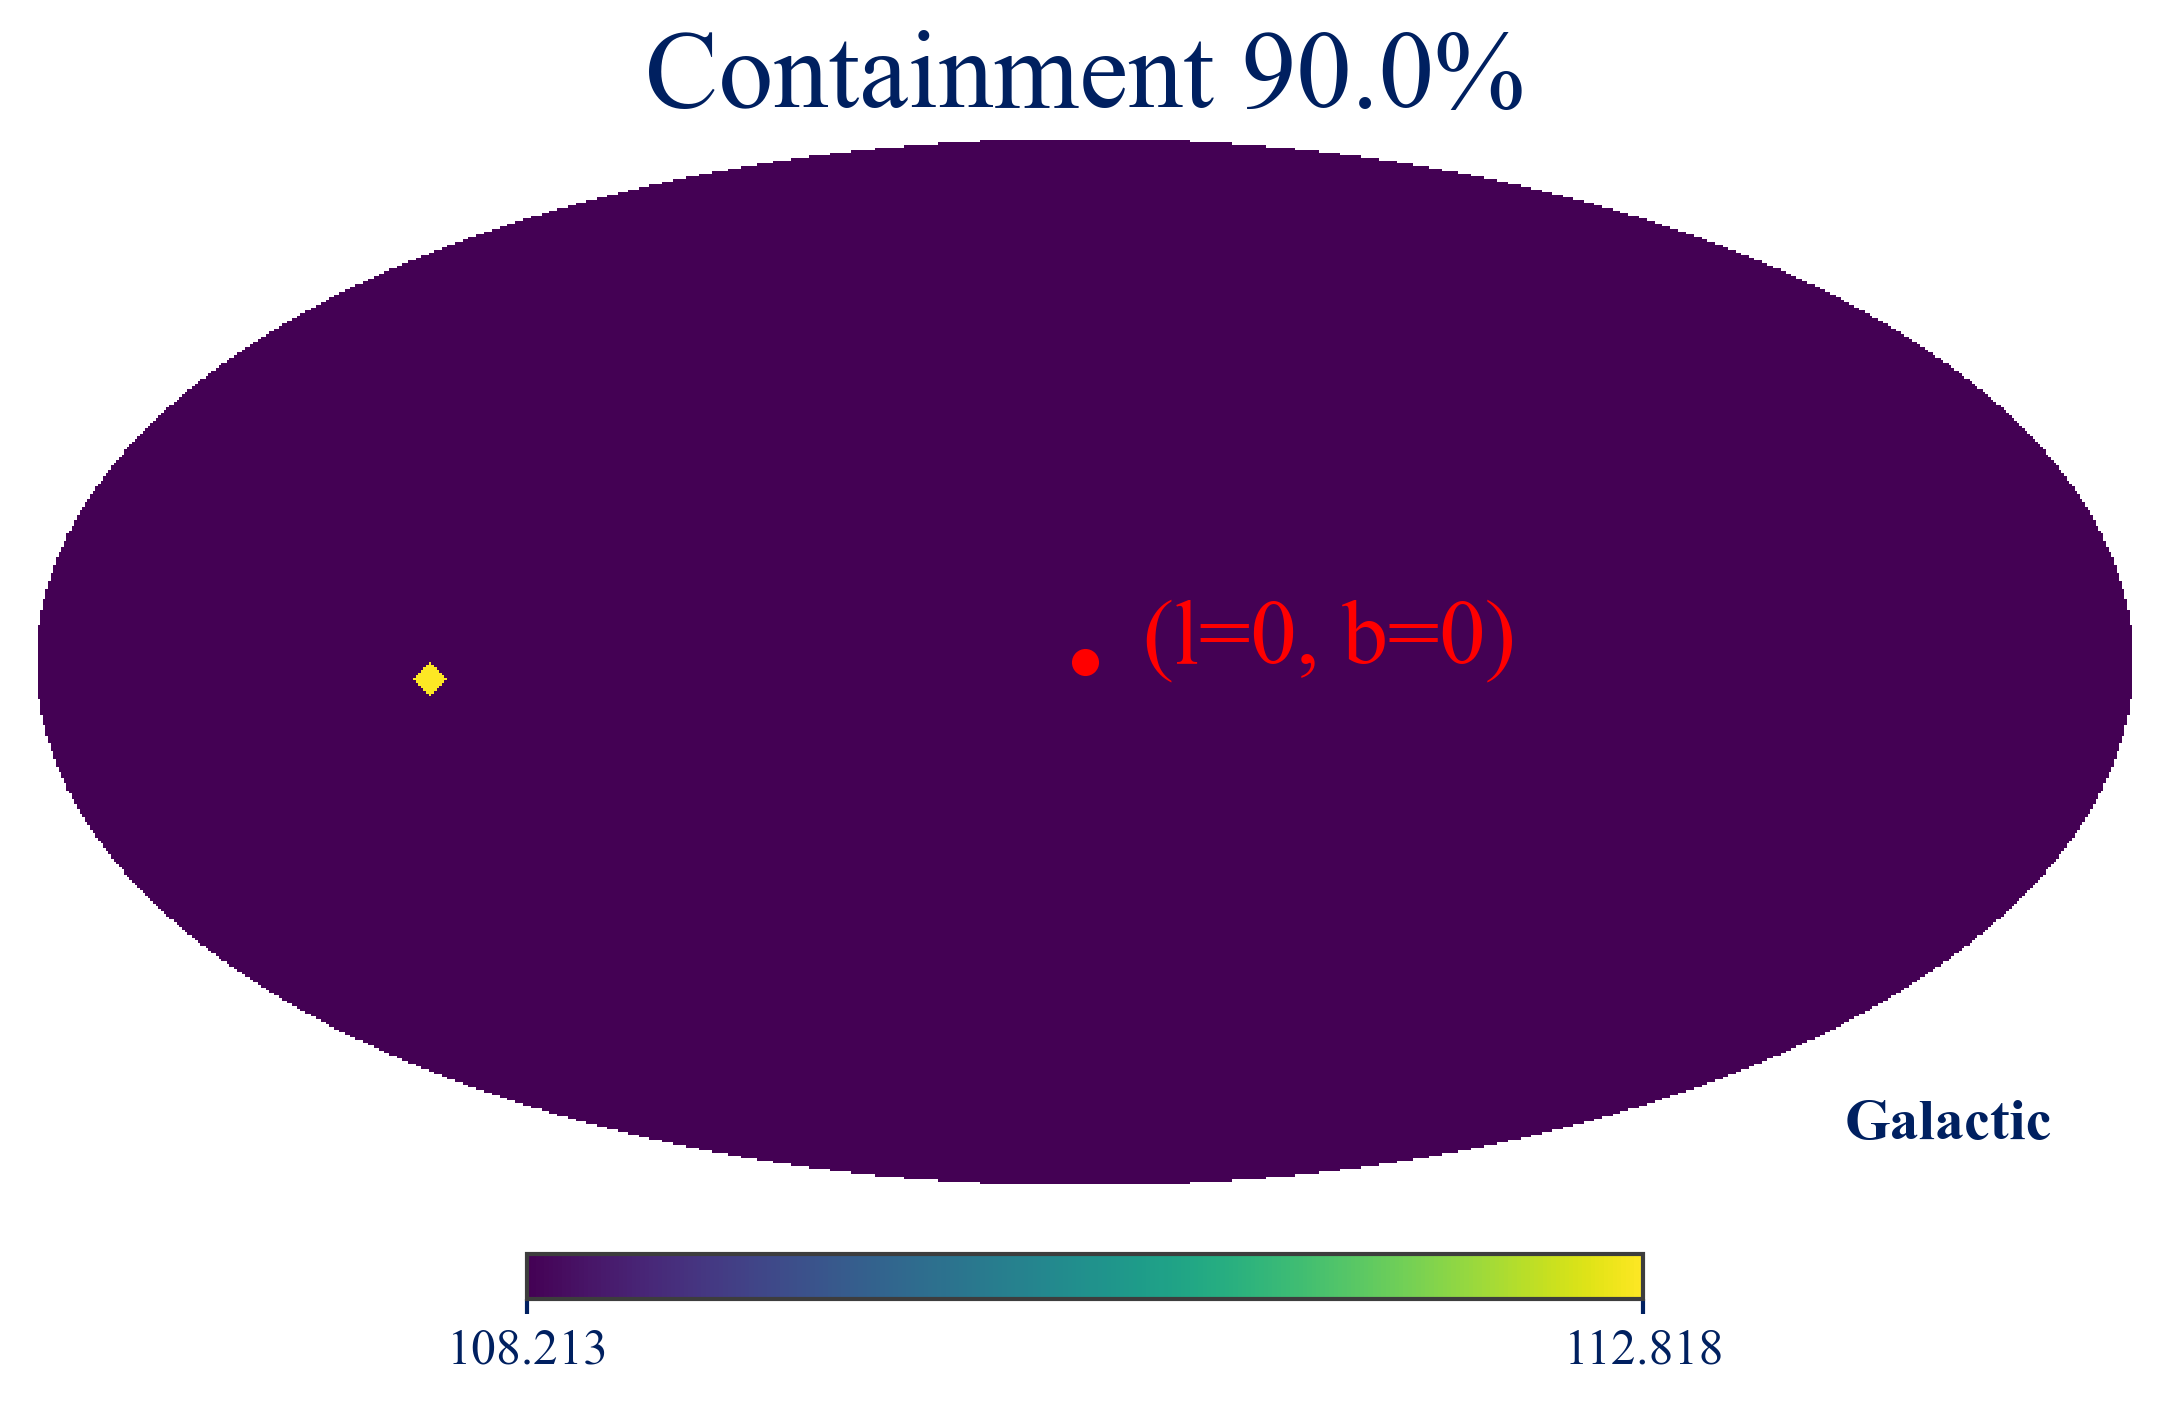

In [ ]:
ts.plot_ts(ts_results, containment = 0.9)

### Image Deconvolution

In [7]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": bg.project(['Em', 'Phi', 'PsiChi']),
                                                              'crab': crab.binned_data.project(['Em', 'Phi', 'PsiChi']),
                                                              'casa': casa.binned_data.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None
                                      )

In [9]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/50 [00:00<?, ?it/s]

[{'iteration': 48,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49650fca0>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x4965b09d0>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x4965b0d60>,
  'background_normalization': {'total': <Quantity 1.03272121>,
   'crab': <Quantity 0.00798776>,
   'casa': <Quantity 0.94612978>},
  'alpha': 1.0,
  'log-likelihood': [<Quantity -120566.73724614>]},
 {'iteration': 49,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x49650eb00>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x4965b1b10>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x4965b1ea0>,
  'background_normalization': {'total': <Quantity 1.03272712>,
   'crab': <Quantity 0.00770264>,
   'casa': <Quantity 0.94613157>},
  'alpha': 1.0,
  'log-likelihood': [<Quantity -120566.69573703>]},
 {'itera

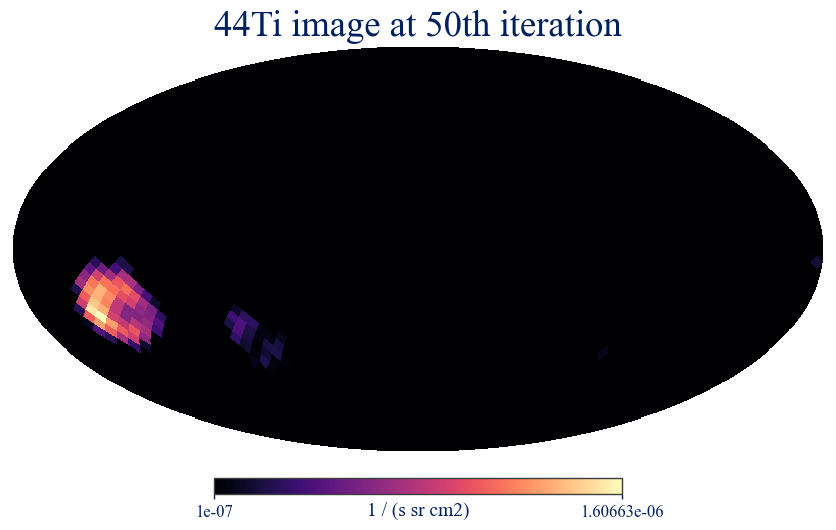

In [10]:
iteration_idx = 49

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

im = image[:,0]
im[im <= 1e-10 * im.unit] = 1e-10 * im.unit

hp.mollview(im, min = 1e-7, norm ='log', unit = str(im.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

plt.show()

## Applying poisson fluctuations to background

### Sanity Checks

In [342]:
baby = bg.project(['Em', 'Phi', 'PsiChi']).todense().contents
np.random.poisson(baby.flatten()[np.where(baby.flatten() > 5)[0]])

array([4, 7, 3, 6, 9, 5, 4, 8, 3, 4, 4, 2, 3, 5, 1, 8, 7])

In [367]:
l = []
for i in range(5000):
    l.append(np.random.poisson(baby).sum() - baby.sum())

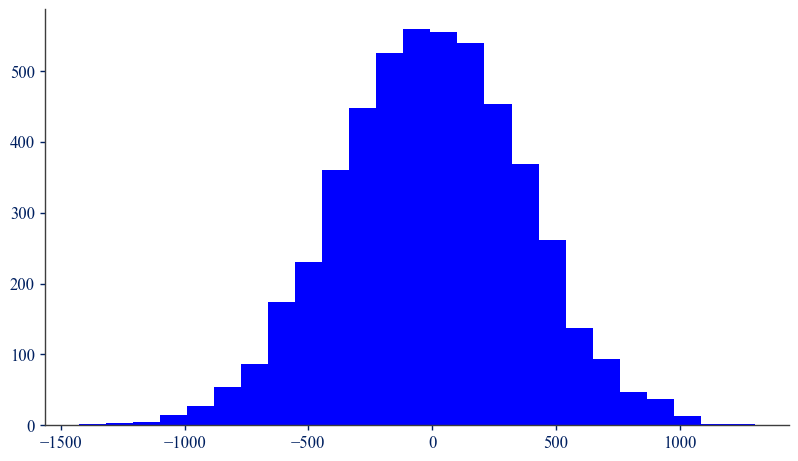

In [368]:
plt.hist(l)
plt.show()

### Image Deconvolution

In [16]:
hist = bg.project(['Em', 'Phi', 'PsiChi']).todense()

new_axes = []

for axis in hist.axes[:2]:
    new_axes += [Axis(axis.edges, label = axis.label,
                    scale = axis.axis_scale)]

axis = hist.axes[2]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

new_bg = Histogram(new_axes,
                           contents = np.random.poisson(hist.contents),
                           sparse=hist.is_sparse,
                           unit=hist.unit)

In [ ]:
# new_bg = deepcopy(bg)
# new_bg = np.random.poisson(bg.project(['Em', 'Phi', 'PsiChi']).todense().contents)

In [12]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": new_bg,},
                                                            #   'crab': crab.binned_data.project(['Em', 'Phi', 'PsiChi']),
                                                            #   'casa': casa.binned_data.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None
                                      )

In [ ]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.override_parameter("deconvolution:parameter_RL:iteration = 200")
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/50 [00:00<?, ?it/s]

: 

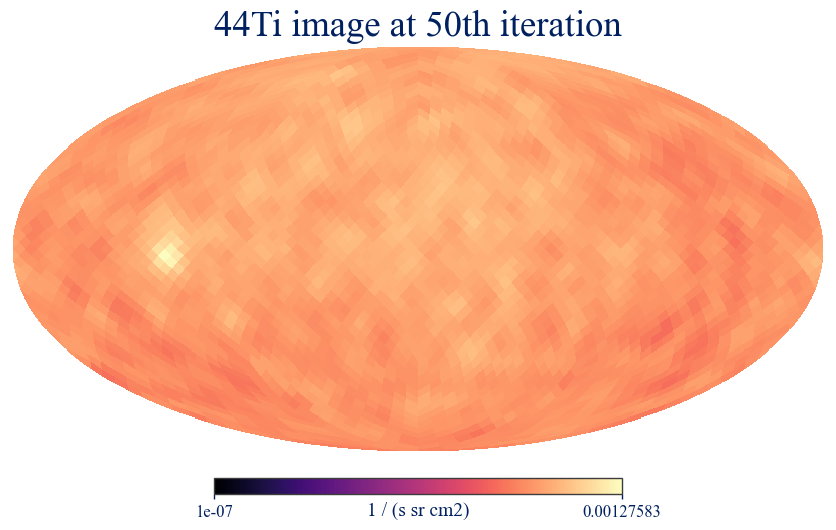

In [14]:
iteration_idx = 49

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

im = image[:,0]
im[im <= 0 * im.unit] = 1e-12 * im.unit

hp.mollview(im, min = 1e-7, norm ='log', unit = str(im.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

plt.show()

**WHY IS THE BACKGROUND NORMALIZATION ALWAYS FALLING TO 0.28 FROM 1.04**

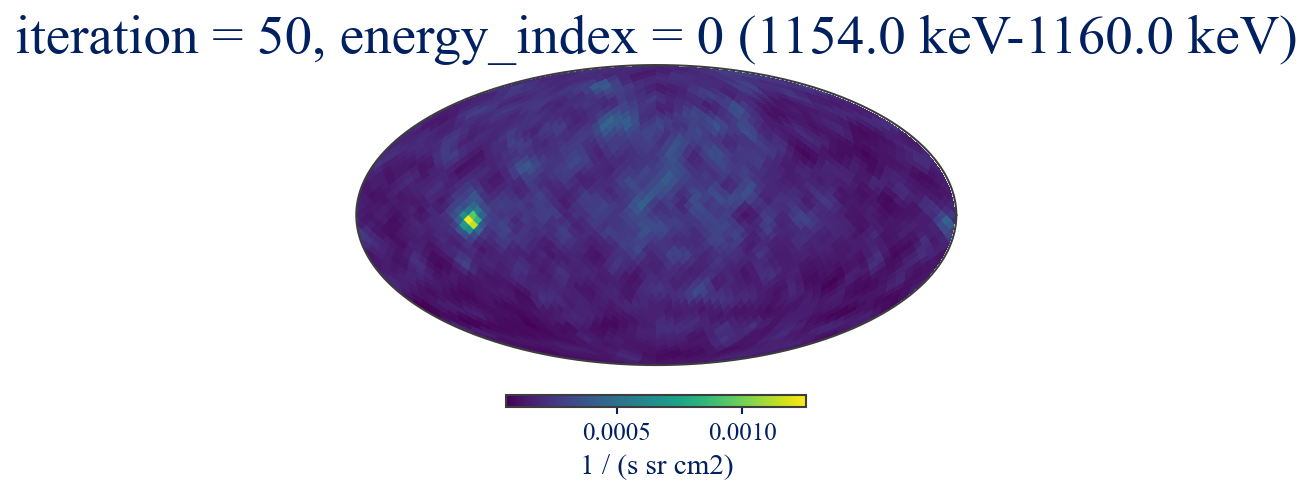

In [410]:
iteration = 49

plot_reconstructed_image(image_deconvolution.results[iteration])

### TS Map

In [17]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.28*new_bg + \
                           crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                           casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = psr_filename,
               cds_frame = "galactic",
               )

4216.143793390216
1108


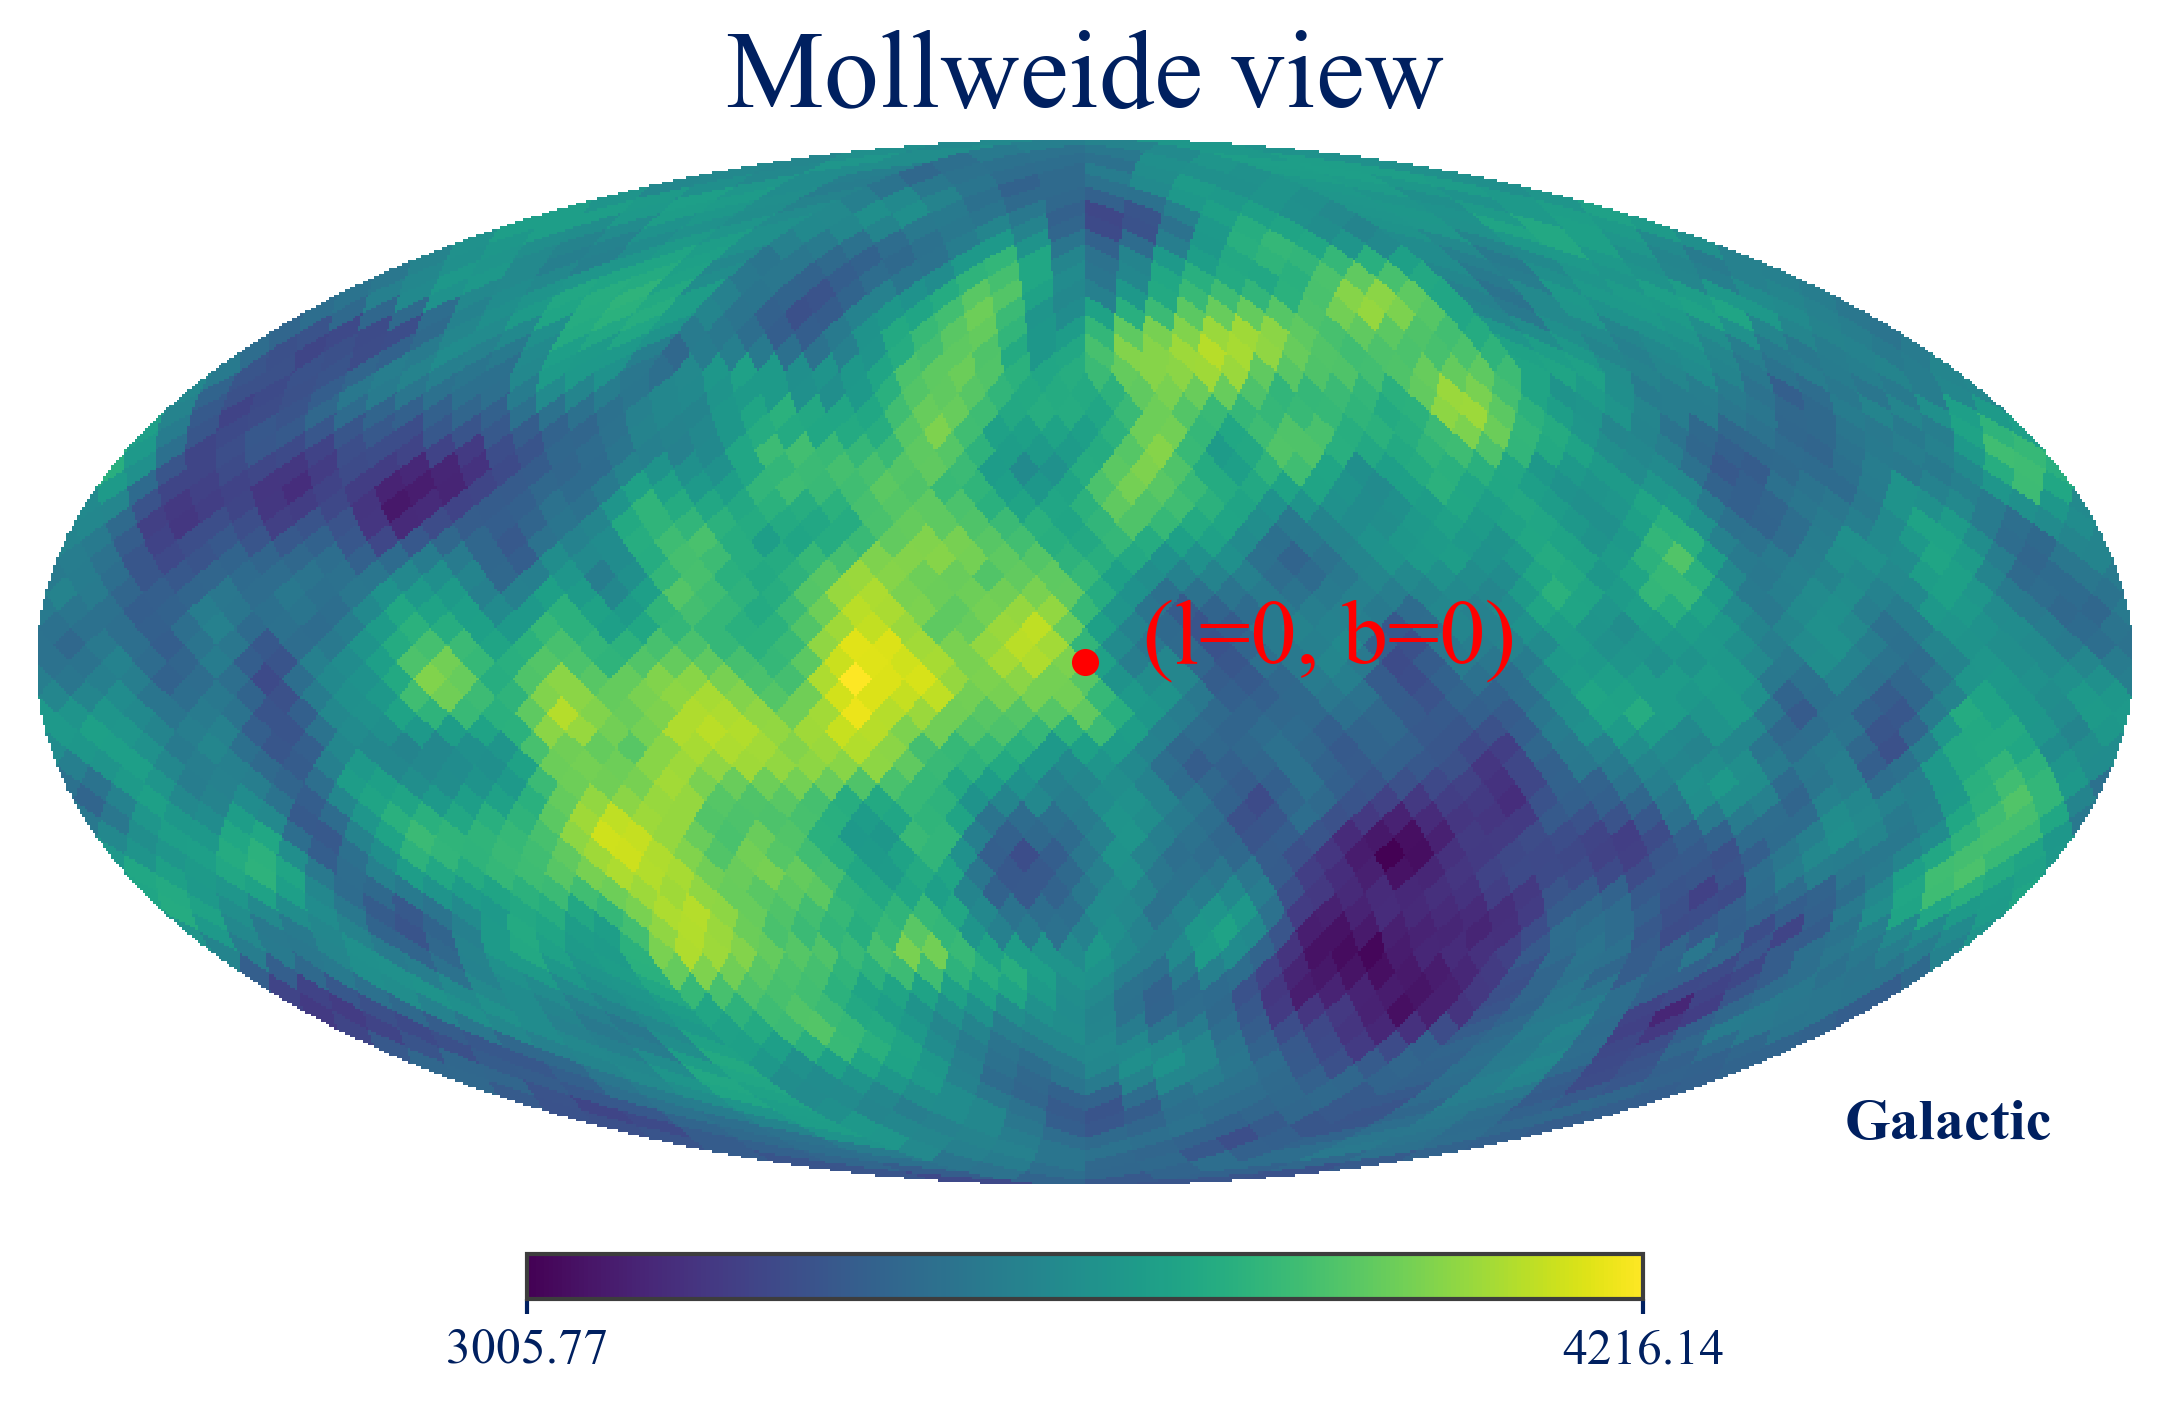

In [18]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [ ]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.28*new_bg,# + \
                        #    crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                        #    casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

5161.5199089618545
1359


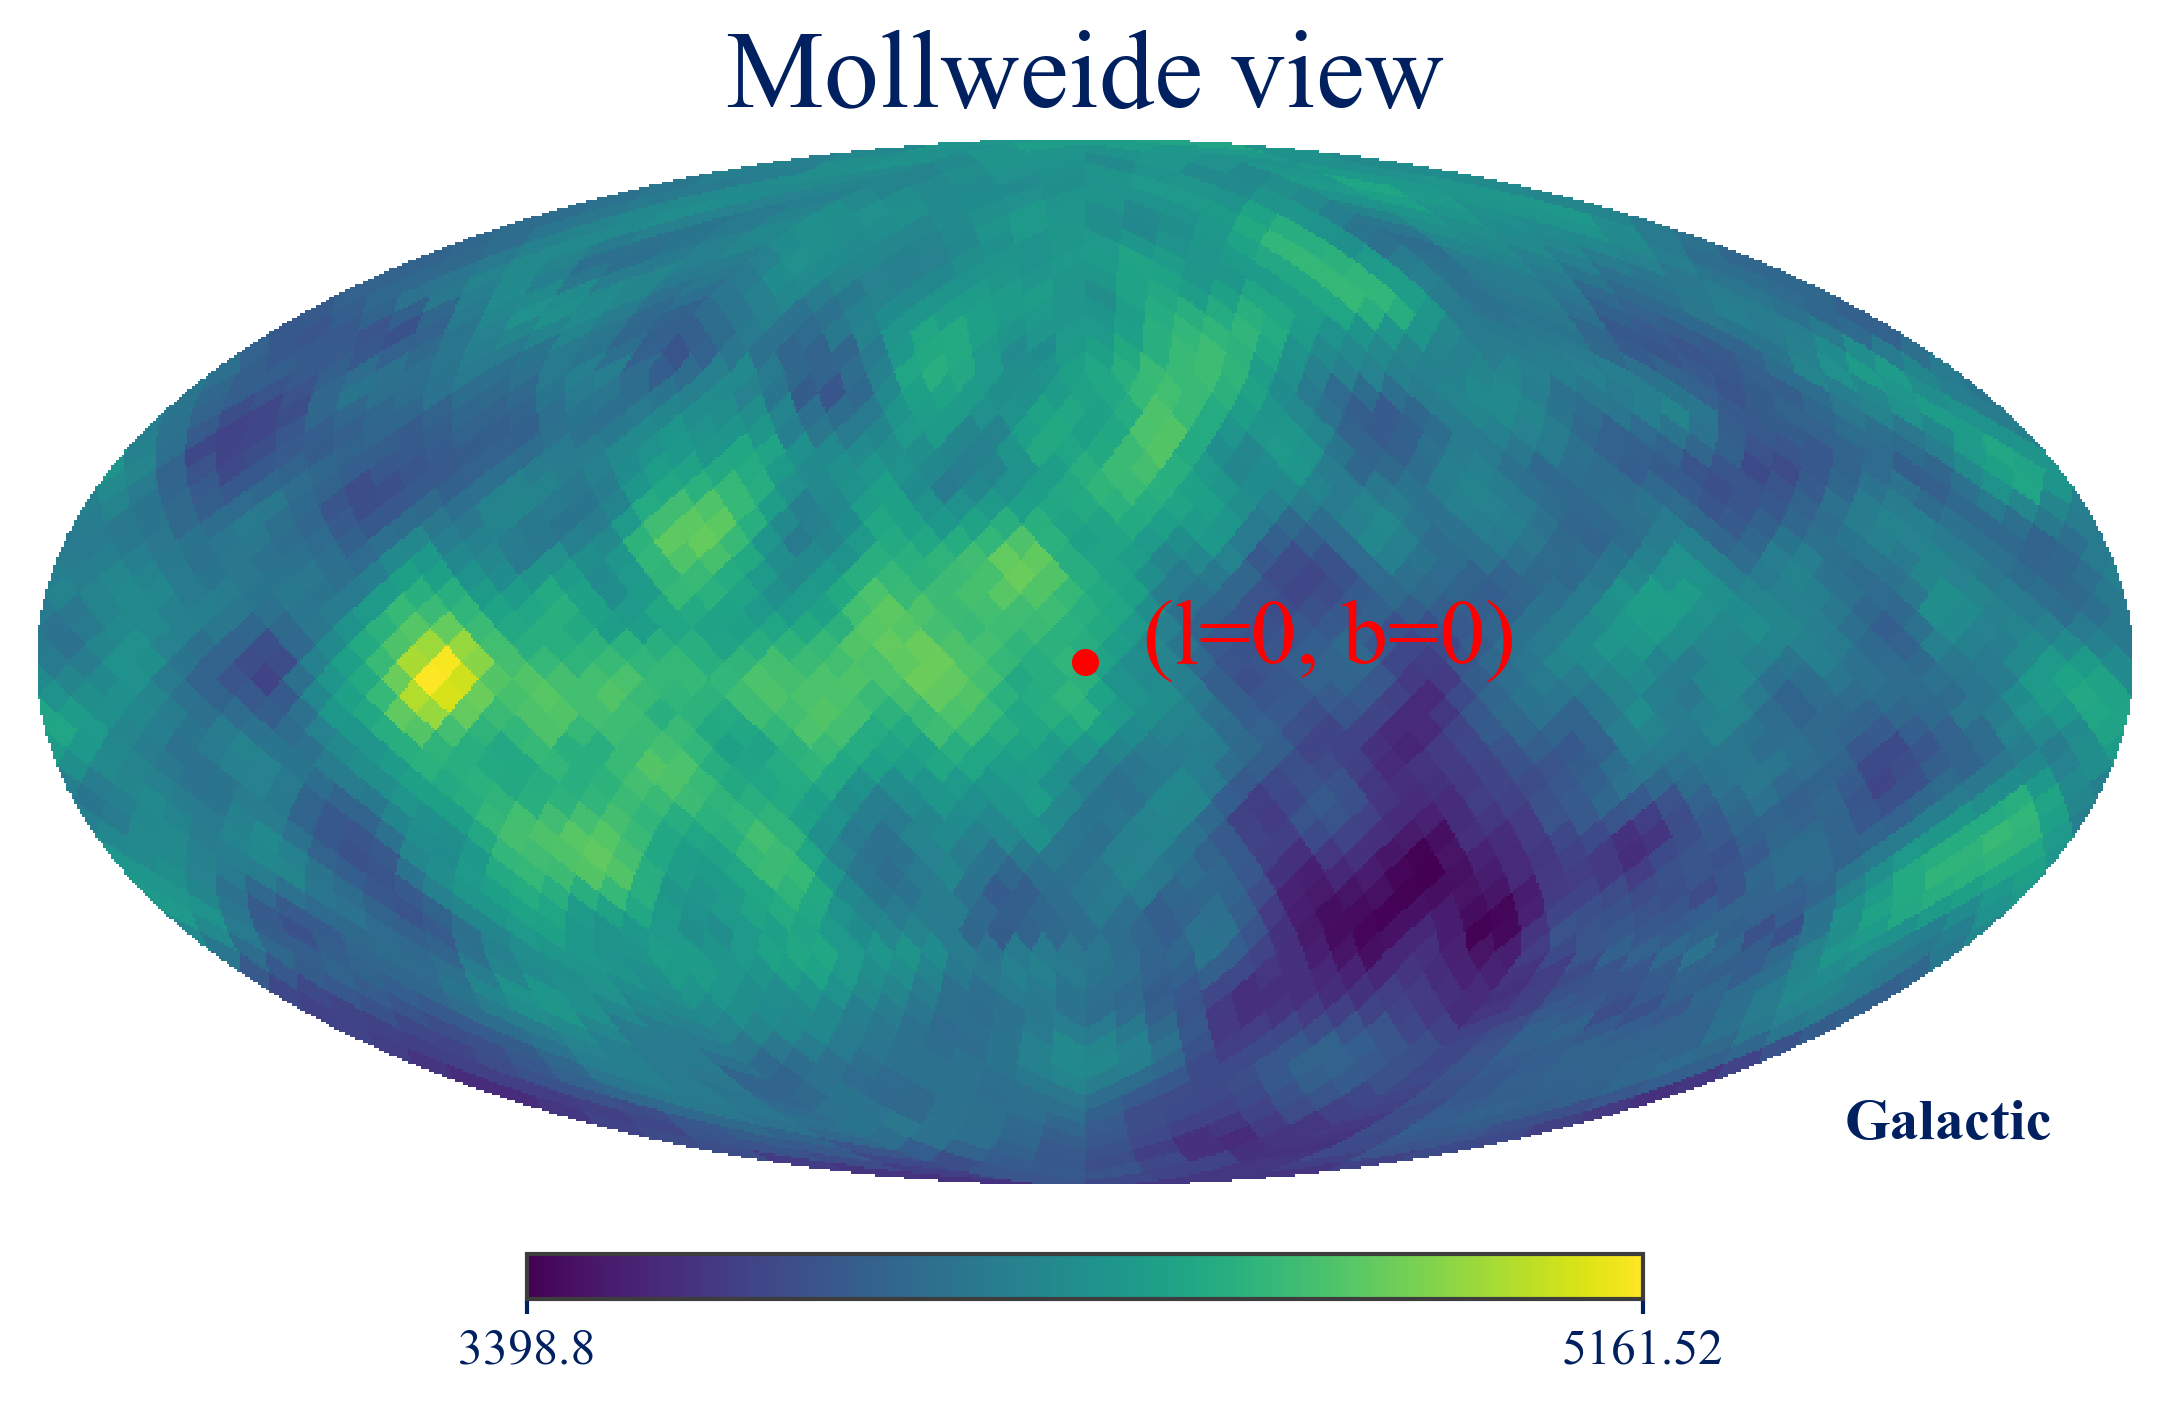

In [ ]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [ ]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.4*new_bg,# + \
                        #    crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                        #    casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

506.49707217780997
1359


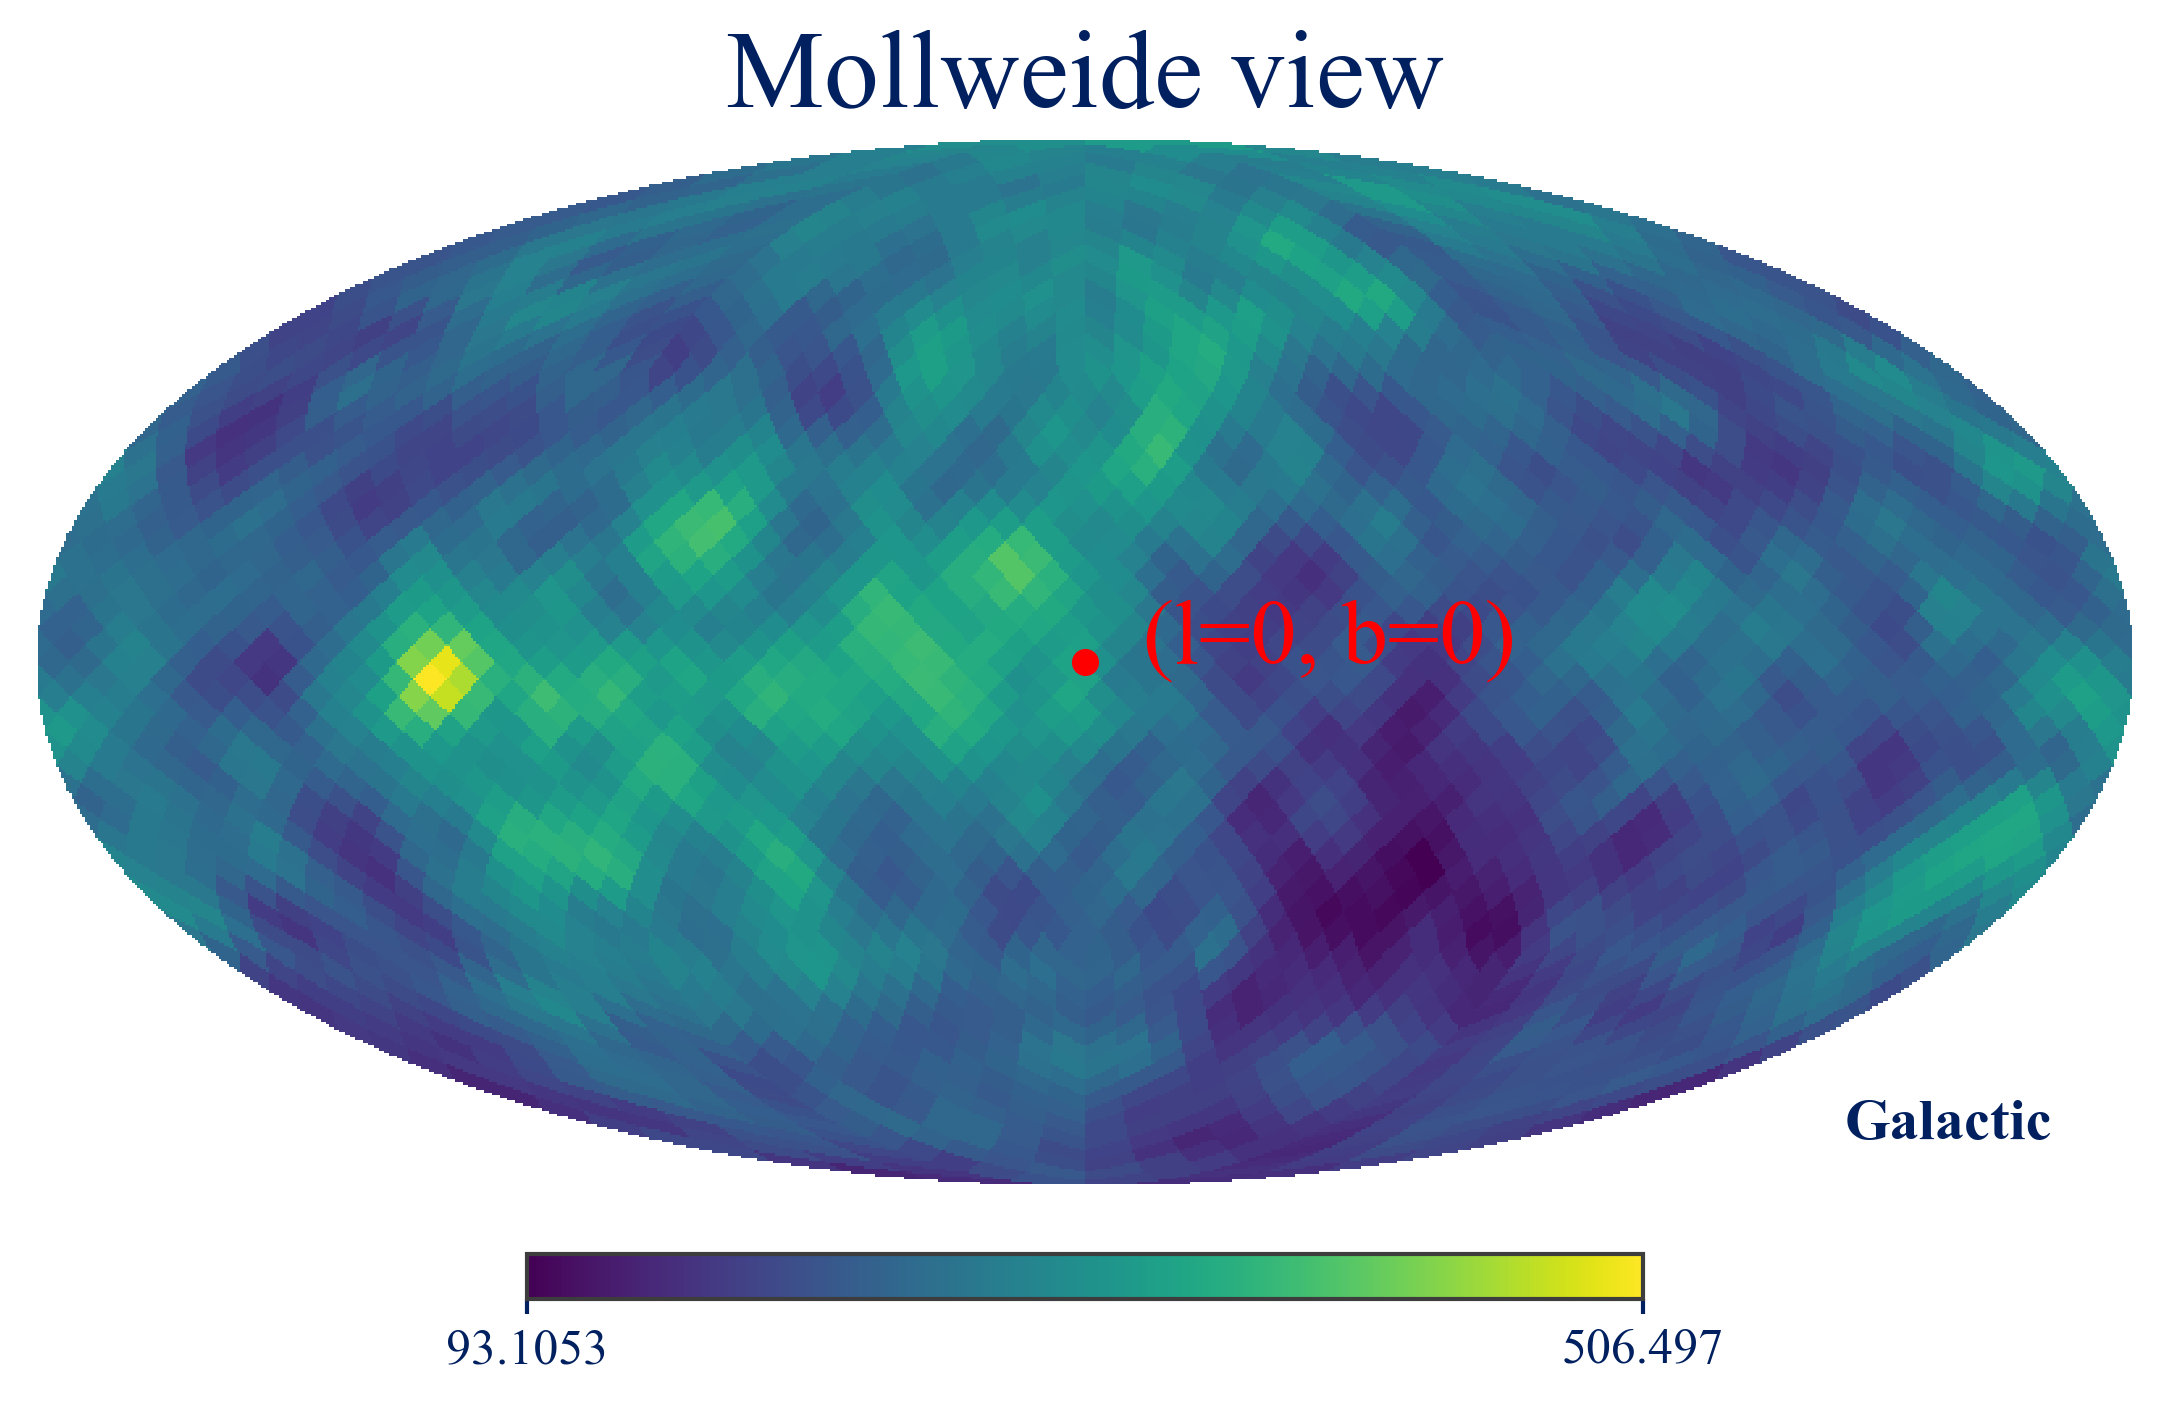

In [420]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)